In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.basemap import shiftgrid

In [2]:
df_rst_on = pd.read_csv("rst_on.csv")
df_rst_off = pd.read_csv("rst_off.csv")
df_rlut_on = pd.read_csv("rlut_on.csv")
df_rlut_off = pd.read_csv("rlut_off.csv")
df_rss_on = pd.read_csv("rss_on.csv")
df_rss_off = pd.read_csv("rss_off.csv")
df_rls_on = pd.read_csv("rls_on.csv")
df_rls_off = pd.read_csv("rls_off.csv")
df_hfls_on = pd.read_csv("hfls_on.csv")
df_hfls_off = pd.read_csv("hfls_off.csv")
df_hfss_on = pd.read_csv("hfss_on.csv")
df_hfss_off = pd.read_csv("hfss_off.csv")

In [44]:
def draw_maps(df,title,values,label,figname):
    #shift 'seam' of map to pacific ocean
    df['lon'] = (df['lon'] + 180) % 360 - 180
    
    map = Basemap(projection='ortho',lat_0=30,lon_0=-50,resolution='l')
    # draw coastlines, country boundaries, fill continents.
    map.drawcoastlines(linewidth=0.25)
    map.drawcountries(linewidth=0.25)
    map.fillcontinents(color='#4863A0',lake_color='#D3D3D3')
    # draw the edge of the map projection region (the projection limb)
    map.drawmapboundary(fill_color='grey')
    # draw lat/lon grid lines every 30 degrees.
    map.drawmeridians(np.arange(0,360,30))
    map.drawparallels(np.arange(-90,90,30))
    
    # make mapgrid using lat and lon values
    lats = np.sort(df['lat'].unique())
    lons = np.sort(df['lon'].unique())
    grid = df.pivot(index='lat', columns='lon', values=values).values
    
    # Create meshgrid for Basemap
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    x, y = map(lon_grid, lat_grid)
    
    cs = map.contourf(x, y, grid, levels=20, cmap='coolwarm')
    cbar = plt.colorbar(cs, orientation='vertical')
    
    # Replace the top tick with "Land"
    ticks = cbar.get_ticks()
    tick_labels = [f"{t:.1f}" for t in ticks]
    
    # If 220 is in ticks, replace it with "Land"
    if 220 in ticks:
        tick_labels[ticks.tolist().index(220)] = "Land"
    
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    cbar.set_label(label)
    
    plt.title(title)
    plt.savefig(figname)
    plt.show()

In [45]:
df_combined_on = pd.merge(df_rst_on, df_rlut_on, on=["lat","lon"])
df_combined_off = pd.merge(df_rst_off, df_rlut_off, on=["lat","lon"])

# Create a new column which is the sum of rst and rss
df_combined_on["total"] = df_combined_on["rst"] + df_combined_on["rlut"]
df_combined_off["total"] = df_combined_off["rst"] + df_combined_off["rlut"]

#surf on
merged_on = pd.merge(df_rss_on, df_rls_on, on=["lat","lon"])
merged_on = pd.merge(merged_on, df_hfls_on, on=["lat","lon"])
merged_on = pd.merge(merged_on, df_hfss_on, on=["lat","lon"])
merged_on['total'] = merged_on['rss'] + merged_on['rls'] + merged_on['hfls'] + merged_on['hfss']

#surf off
merged_off = pd.merge(df_rss_off, df_rls_off, on=["lat","lon"])
merged_off = pd.merge(merged_off, df_hfls_off, on=["lat","lon"])
merged_off = pd.merge(merged_off, df_hfss_off, on=["lat","lon"])
merged_off['total'] = merged_off['rss'] + merged_off['rls'] + merged_off['hfls'] + merged_off['hfss']


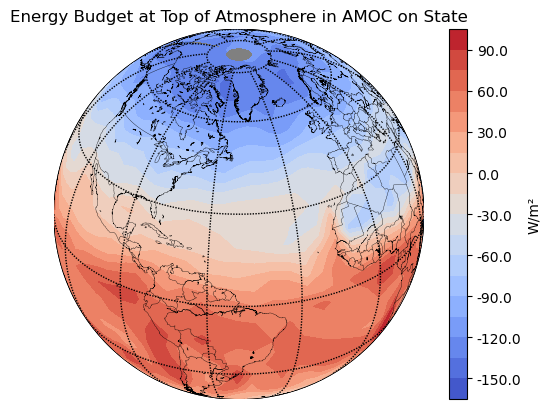

In [46]:
draw_maps(df_combined_on,"Energy Budget at Top of Atmosphere in AMOC on State","total","W/m²",
          "energy_budget_toa_on.png")

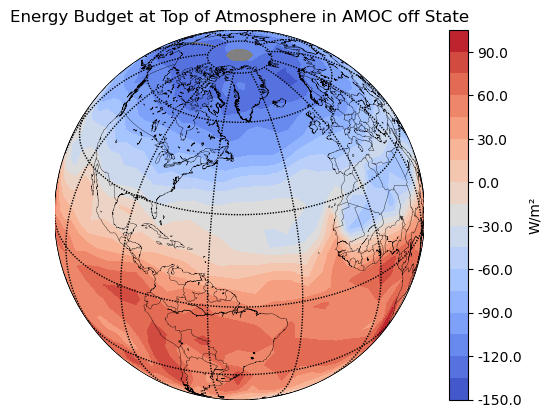

In [47]:
draw_maps(df_combined_off,"Energy Budget at Top of Atmosphere in AMOC off State","total","W/m²",
          "energy_budget_toa_off.png")

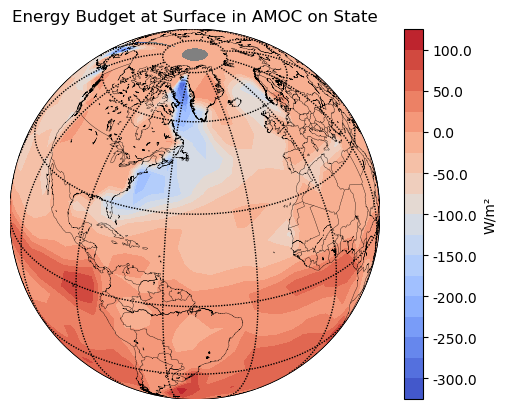

In [48]:
draw_maps(merged_on,'Energy Budget at Surface in AMOC on State','total',"W/m²","energy_budget_surf_on.png")

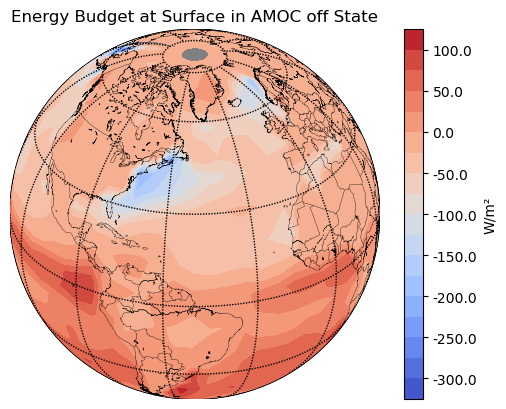

In [49]:
draw_maps(merged_off,'Energy Budget at Surface in AMOC off State','total',"W/m²","energy_budget_surf_off.png")